In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df=pd.read_excel(r"C:\Users\USER\Downloads\Warangal_West_Complete_Results.xlsx")

In [4]:
df.tail()

,Sl. No.,Polling Station No.,Polling Station Name,DASYAM VINAY BHASKER,NANH RAJINDER REDDY,MADAKAPU RAM KUMAR,RAD PADMA,ILAPURAM VENUCUARY,KOGLA ROOPA,GADDAM NAGARJUNA,...,KRISHNA K,GIUIULA SRINIVAS REDDY,GUIRAMA JAKKAAH,BOMMAGANI BHARGAV,P. SATHYA PRAKASH,Total of Valid Votes,No. Of Rejected Votes,NOTA,Total,No. Of Tendered Votes
240,241,240,Naimnagar,313,488,7,35,1,7,1,...,0,0,0,2,1,870,0,16,886.0,0.0
241,242,241,Lashkar Singarm,305,418,7,71,3,8,1,...,0,2,1,0,1,827,0,16,843.0,0.0
242,243,242,Lashkar Singarm,323,394,2,132,1,1,1,...,1,2,0,1,1,868,0,10,878.0,0.0
243,244,243,Lashkar Singarm,245,355,0,23,0,5,1,...,1,1,2,1,1,645,0,7,652.0,0.0
244,245,244,Vidhya Nagar,369,496,5,75,0,1,1,...,0,1,1,0,2,965,0,22,987.0,0.0


In [5]:
df.rename(columns={'DASYAM VINAY BHASKER':'BRS',
                   'NANH RAJINDER REDDY':'INC',
                   'MADAKAPU RAM KUMAR':'BSP', 
                   'RAD PADMA':'BJP', 
                   
                  },inplace=True)

In [6]:
df.keys()

Index(['Sl. No.', 'Polling Station No.', 'Polling Station Name', 'BRS', 'INC',
       'BSP', 'BJP', 'ILAPURAM VENUCUARY', 'KOGLA ROOPA', 'GADDAM NAGARJUNA',
       'YOUGRIDAR GOUD', 'SYED SHAI HASHIR', 'MOHAMMED KHALEE UDDIN',
       'KRISHNA K', 'GIUIULA SRINIVAS REDDY', 'GUIRAMA JAKKAAH',
       'BOMMAGANI BHARGAV', 'P. SATHYA PRAKASH', 'Total of Valid Votes',
       'No. Of Rejected Votes', 'NOTA', 'Total', 'No. Of Tendered Votes'],
      dtype='object')

In [7]:
cols=['BRS','INC', 'BSP', 'BJP','ILAPURAM VENUCUARY', 'KOGLA ROOPA', 'GADDAM NAGARJUNA','YOUGRIDAR GOUD', 'SYED SHAI HASHIR', 'MOHAMMED KHALEE UDDIN','KRISHNA K', 'GIUIULA SRINIVAS REDDY', 'GUIRAMA JAKKAAH',
       'BOMMAGANI BHARGAV', 'P. SATHYA PRAKASH','NOTA','No. Of Rejected Votes']
percentages = {}

for c in cols:
    percentages[c] = (df[c].sum() / df['Total of Valid Votes'].sum()) * 100

per=pd.DataFrame(percentages, index=['Percentage']).T
print(round(per))






                        Percentage
BRS                           36.0
INC                           44.0
BSP                            1.0
BJP                           19.0
ILAPURAM VENUCUARY             0.0
KOGLA ROOPA                    0.0
GADDAM NAGARJUNA               0.0
YOUGRIDAR GOUD                 1.0
SYED SHAI HASHIR               0.0
MOHAMMED KHALEE UDDIN          0.0
KRISHNA K                      0.0
GIUIULA SRINIVAS REDDY         0.0
GUIRAMA JAKKAAH                0.0
BOMMAGANI BHARGAV              0.0
P. SATHYA PRAKASH              1.0
NOTA                           2.0
No. Of Rejected Votes          0.0


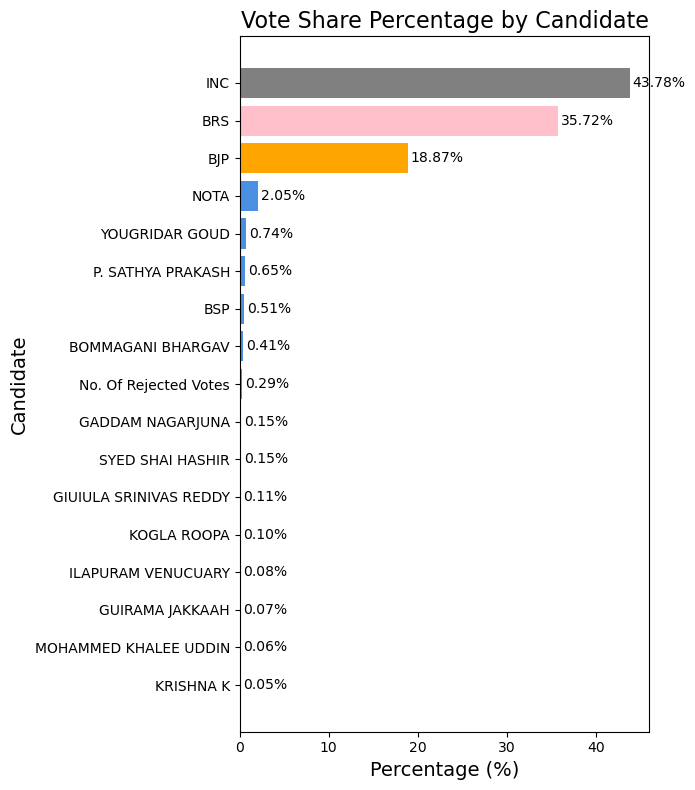

In [8]:
# --- Sort dataframe highest to lowest ---
per_sorted = per.sort_values(by='Percentage', ascending=True)   

colors = []

for candidate in per_sorted.index:
    if candidate == 'BJP':
        colors.append('orange')
    elif candidate == 'BRS':
        colors.append('pink')
    elif candidate == 'INC':
        colors.append('gray')
    else:
        colors.append('#4A90E2') 

# --- Plot ---
plt.figure(figsize=(7, 8))

bars = plt.barh(per_sorted.index, per_sorted['Percentage'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}%', va='center', fontsize=10)

plt.title("Vote Share Percentage by Candidate", fontsize=16)
plt.xlabel("Percentage (%)", fontsize=14)
plt.ylabel("Candidate", fontsize=14)

plt.tight_layout()
plt.show()


In [8]:
main_candidates = [
    'BRS',
    'BJP',
    'INC','NOTA'
]

other_candidates = [c for c in cols if c not in main_candidates]


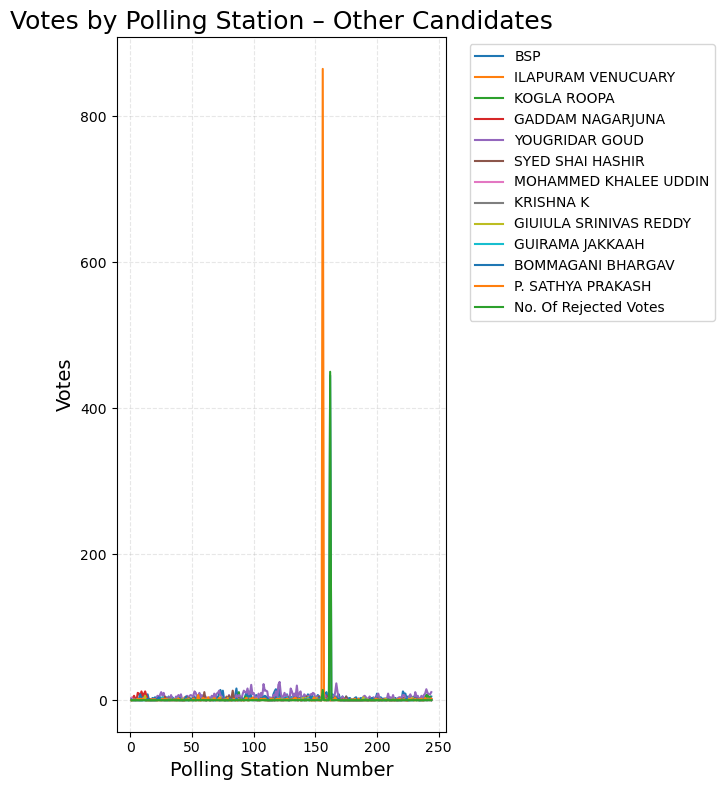

In [10]:
plt.figure(figsize=(7, 8))

for c in other_candidates:
    sns.lineplot(x=df['Polling Station No.'], y=df[c], label=c)

plt.title("Votes by Polling Station – Other Candidates", fontsize=18)
plt.xlabel("Polling Station Number", fontsize=14)
plt.ylabel("Votes", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
count_less_than_200 = (df['BJP'] < 200).sum()
print("Polling stations where BJP got < 200 votes:", count_less_than_200)



Polling stations where BJP got < 200 votes: 220


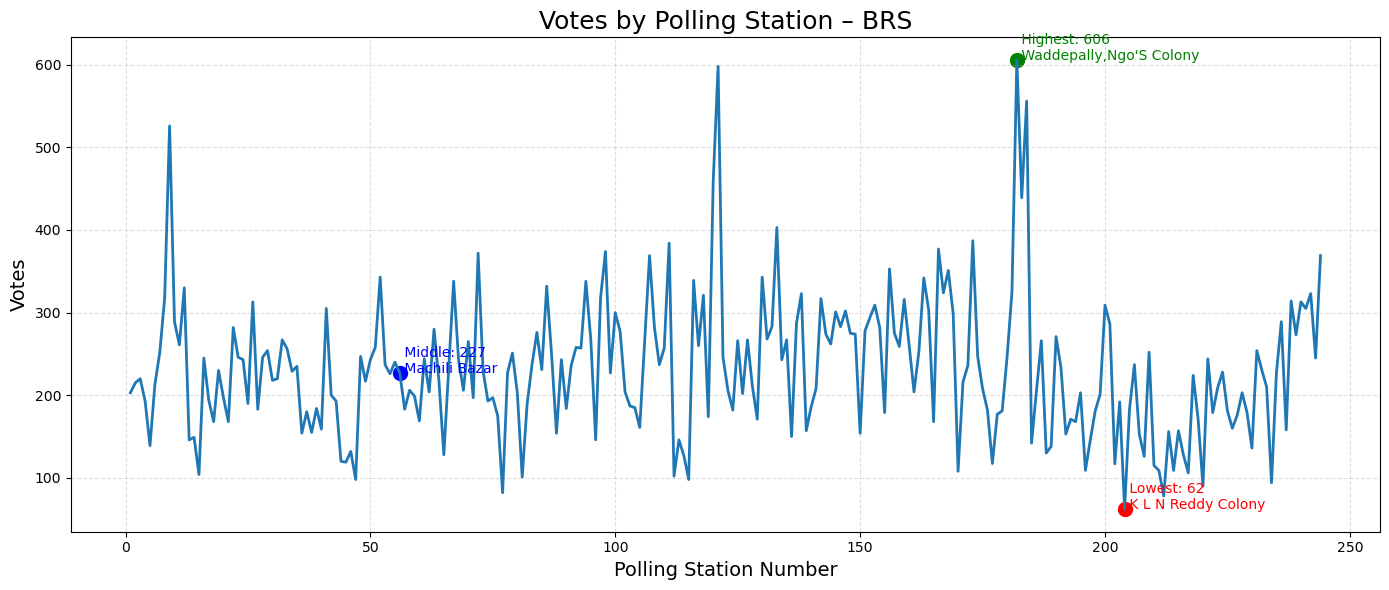

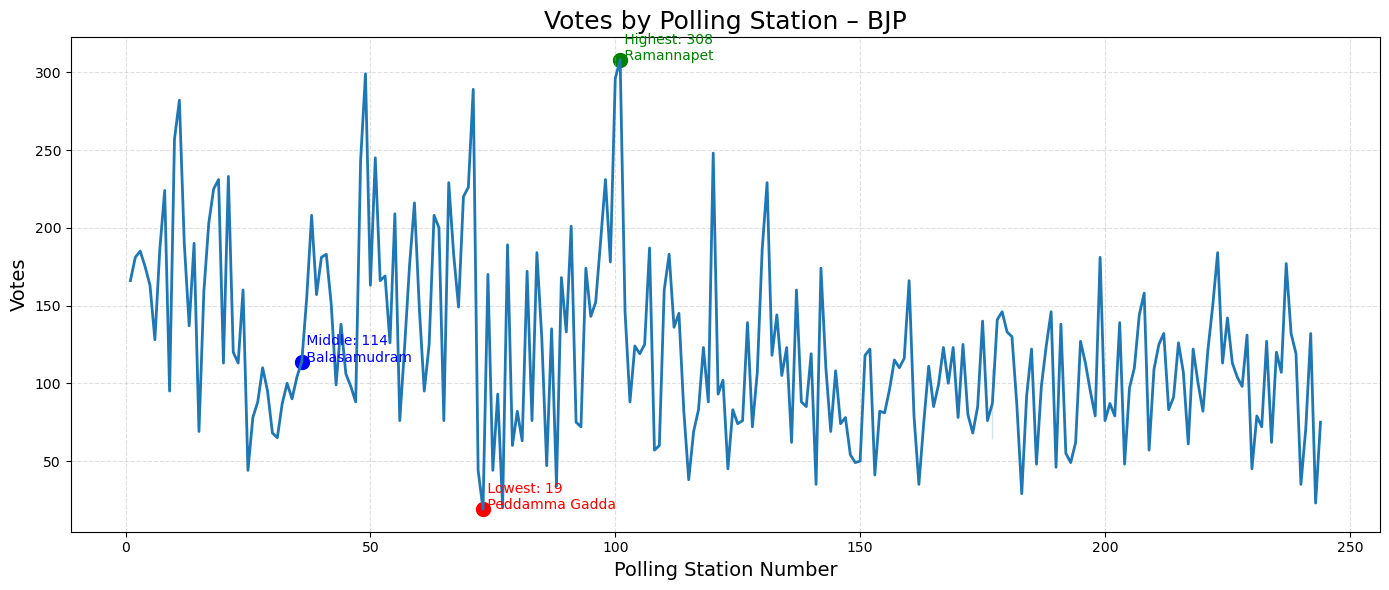

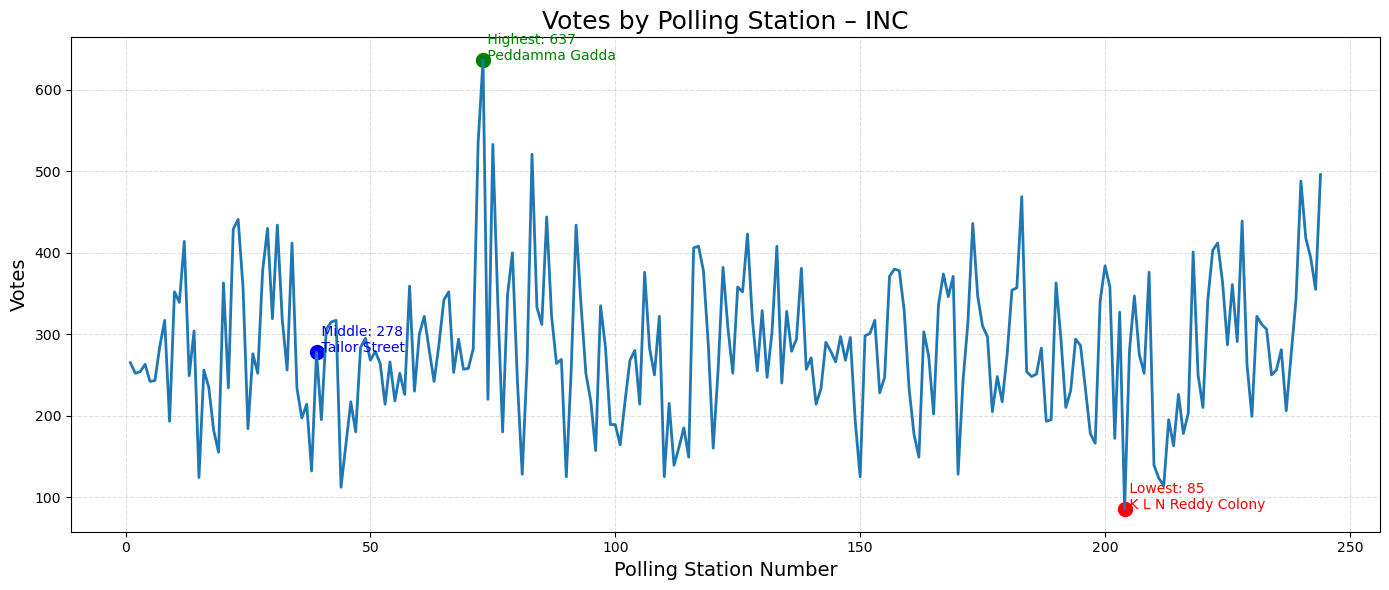

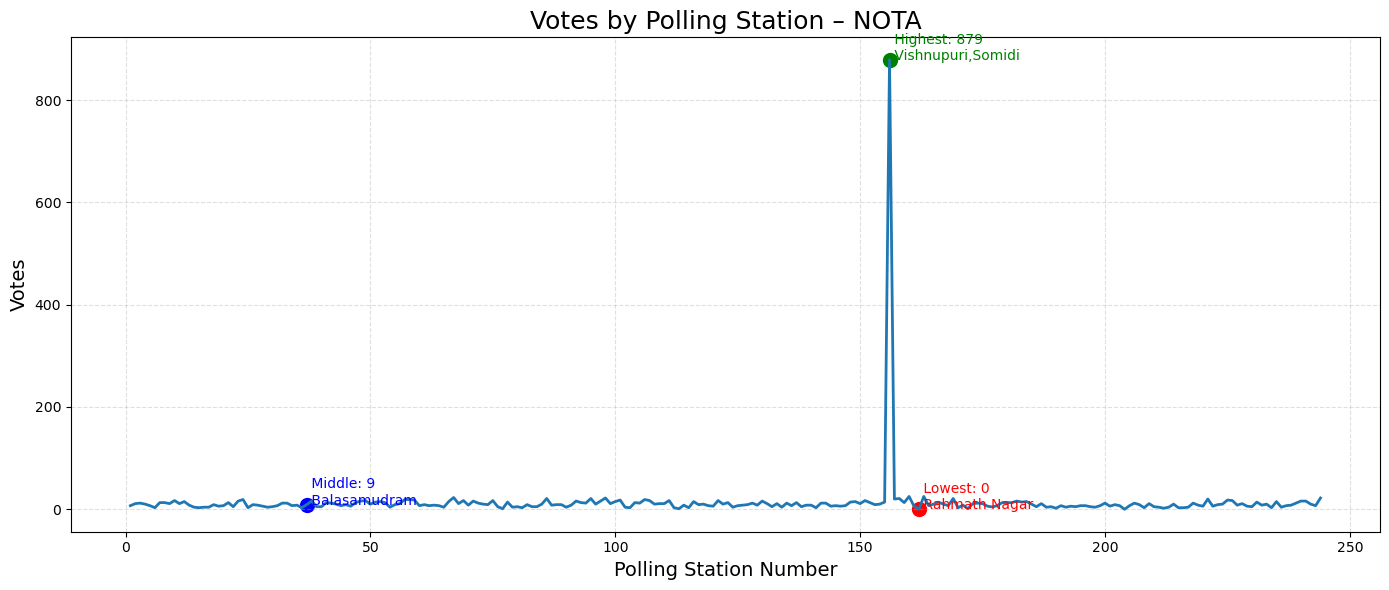

In [12]:


for c in main_candidates:
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=df['Polling Station No.'], y=df[c], linewidth=2)

    # Find highest, lowest, and middle values
    max_idx = df[c].idxmax()
    min_idx = df[c].idxmin()
    
    sorted_vals = df[c].sort_values()
    mid_value = sorted_vals.iloc[len(sorted_vals)//2]
    mid_idx = sorted_vals.index[len(sorted_vals)//2]

    # Extract x, y, and station names
    max_x, max_y = df.loc[max_idx, 'Polling Station No.'], df.loc[max_idx, c]
    min_x, min_y = df.loc[min_idx, 'Polling Station No.'], df.loc[min_idx, c]
    mid_x, mid_y = df.loc[mid_idx, 'Polling Station No.'], df.loc[mid_idx, c]

    max_name = df.loc[max_idx, 'Polling Station Name']
    min_name = df.loc[min_idx, 'Polling Station Name']
    mid_name = df.loc[mid_idx, 'Polling Station Name']

    # Label highest point
    plt.scatter(max_x, max_y, color="green", s=100, label="Highest")
    plt.text(max_x, max_y, 
             f" Highest: {max_y}\n {max_name}", 
             fontsize=10, color="green")

    # Label lowest point
    plt.scatter(min_x, min_y, color="red", s=100, label="Lowest")
    plt.text(min_x, min_y, 
             f" Lowest: {min_y}\n {min_name}", 
             fontsize=10, color="red")

    # Label middle point
    plt.scatter(mid_x, mid_y, color="blue", s=100, label="Middle")
    plt.text(mid_x, mid_y, 
             f" Middle: {mid_y}\n {mid_name}", 
             fontsize=10, color="blue")

    # Titles & labels
    plt.title(f"Votes by Polling Station – {c}", fontsize=18)
    plt.xlabel("Polling Station Number", fontsize=14)
    plt.ylabel("Votes", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


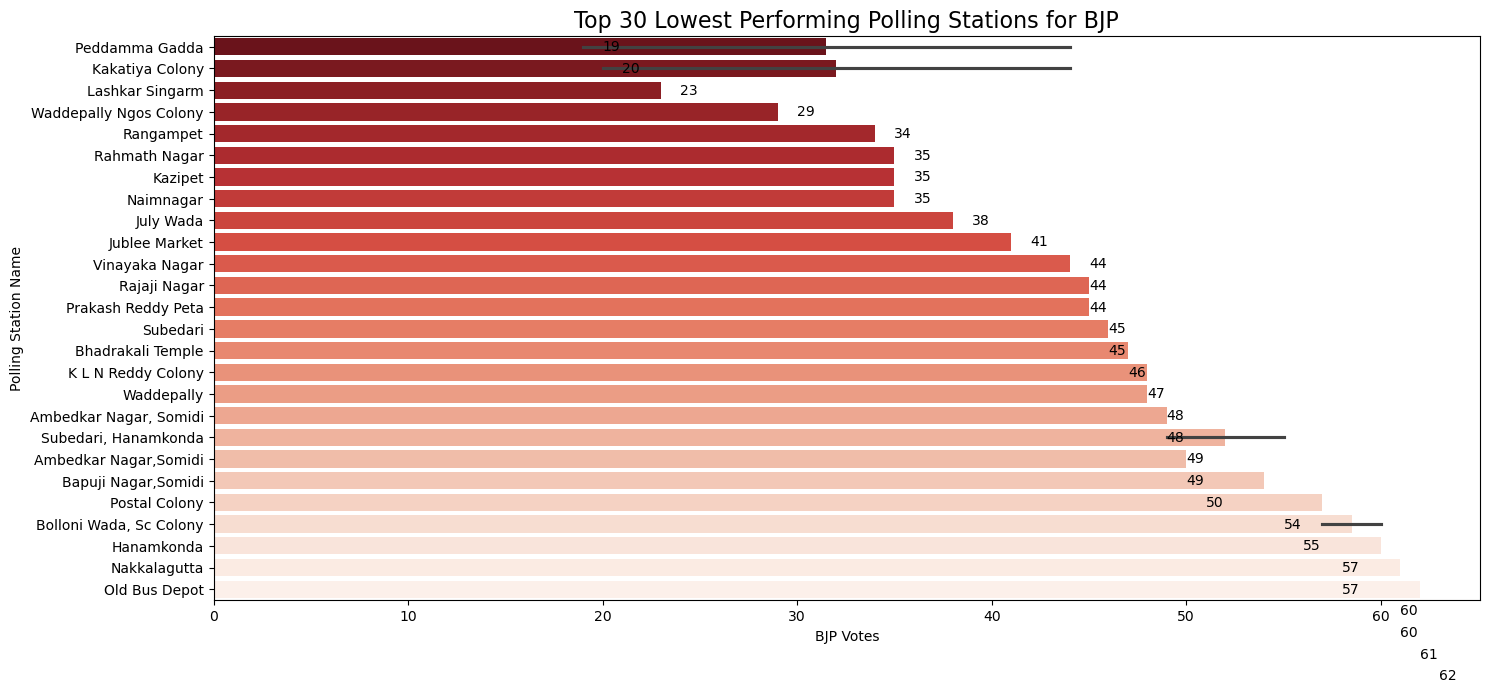

In [14]:
# Sort by BJP votes (ascending) and select top 10 lowest
lowest10_bjp = df.sort_values(by='BJP', ascending=True).head(30)[[
    'Polling Station No.',
    'Polling Station Name',
    'BJP'
]]

lowest10_bjp
plt.figure(figsize=(15,7))
ax = sns.barplot(
    data=lowest10_bjp,
    y='Polling Station Name',
    x='BJP',
    palette='Reds_r',hue='Polling Station Name',legend=False
)

# Add labels
for i, v in enumerate(lowest10_bjp['BJP']):
    ax.text(v + 1, i, str(v), va='center')

plt.title("Top 30 Lowest Performing Polling Stations for BJP", fontsize=16)
plt.xlabel("BJP Votes")
plt.ylabel("Polling Station Name")
plt.tight_layout()
plt.show()



C:\Users\USER\AppData\Local\Temp\ipykernel_1576\927445033.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


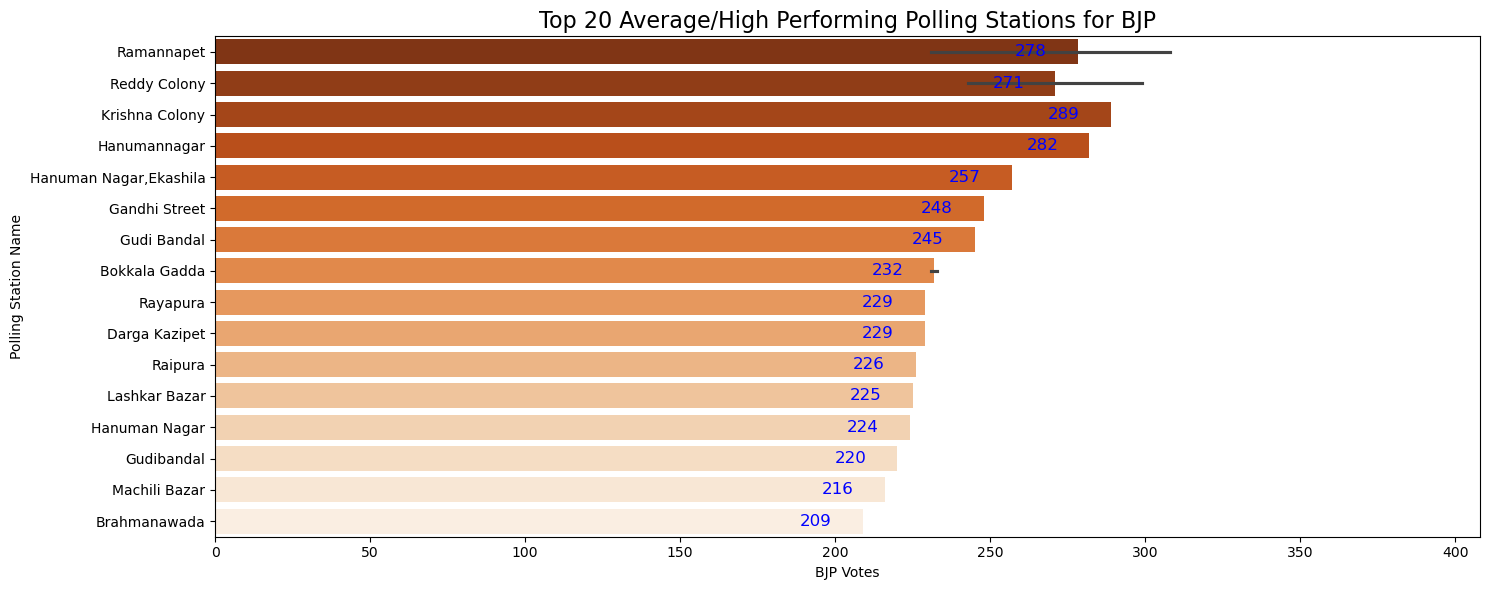

In [15]:
# Sort by BJP votes (descending)
top25_bjp = df.sort_values(by='BJP', ascending=False).head(20)[[
    'Polling Station No.',
    'Polling Station Name',
    'BJP'
]]

plt.figure(figsize=(15,6))

ax = sns.barplot(
    data=top25_bjp,
    y='Polling Station Name',
    x='BJP',
    palette='Oranges_r',
    dodge=False
)

max_vote = top25_bjp['BJP'].max()

# --- USE BAR CONTAINERS ---
bars = ax.patches   

for bar in bars:
    width = bar.get_width()        # BJP votes
    y = bar.get_y() + bar.get_height()/2   # correct vertical center

    if width < max_vote * 0.30:
        # small bar: label outside
        ax.text(width + 10, y, int(width),
                va='center', ha='left', fontsize=12, color='black')
    else:
        # large bar: label inside
        ax.text(width - 10, y, int(width),
                va='center', ha='right', fontsize=12, color='blue')

# Expand x-range
ax.set_xlim(0, max_vote + 100)

plt.title("Top 20 Average/High Performing Polling Stations for BJP", fontsize=16)
plt.xlabel("BJP Votes")
plt.ylabel("Polling Station Name")
plt.tight_layout()
plt.show()


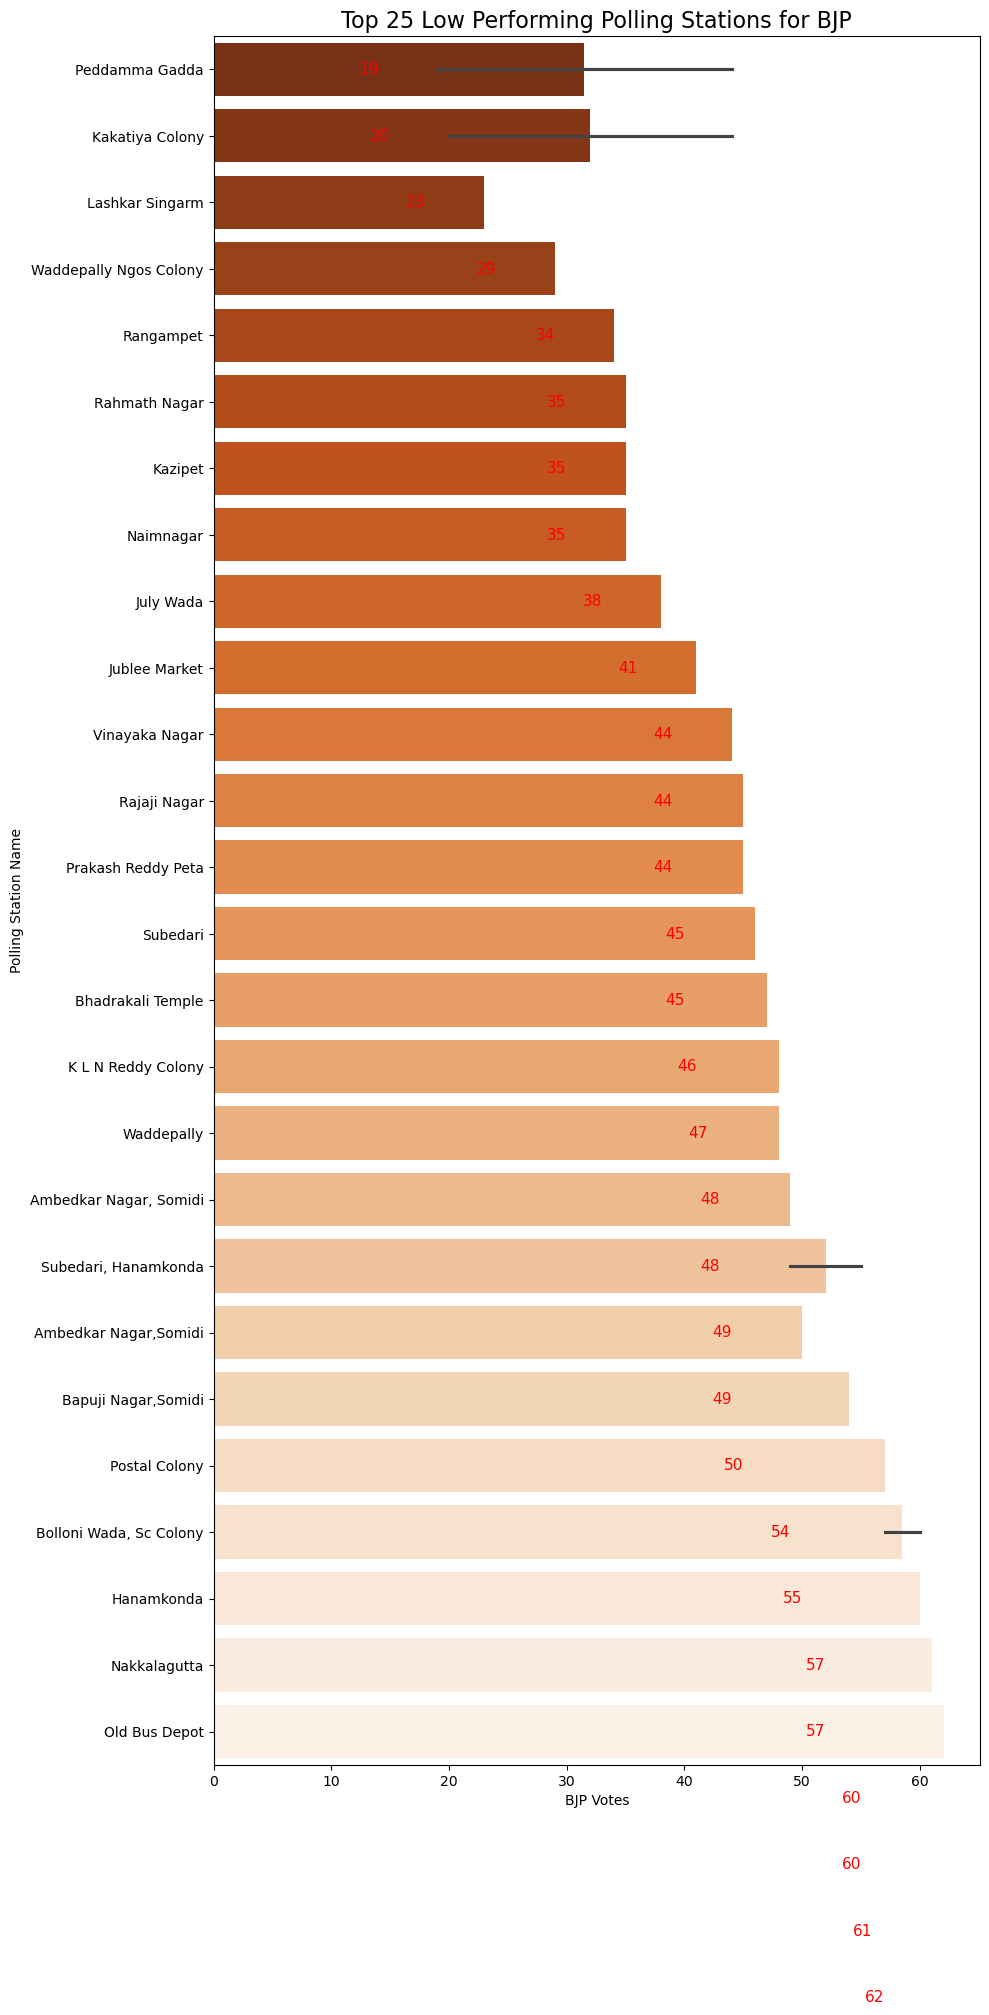

In [16]:
plt.figure(figsize=(10,20))

ax = sns.barplot(
    data=lowest10_bjp,
    y='Polling Station Name',
    x='BJP',
    hue='Polling Station Name',
    palette='Oranges_r',
    dodge=False,
    legend=False
)

max_vote = lowest10_bjp['BJP'].max()

# SMART LABEL PLACEMENT
for i, v in enumerate(lowest10_bjp['BJP']):
    if v > max_vote * 0.30:   # bar is large → label inside
        ax.text(v - 5, i, str(v), va='center', ha='right', color='red', fontsize=11)
    else:                     # bar is small → label outside
        ax.text(v + 5, i, str(v), va='center', ha='left', color='black', fontsize=11)

plt.title("Top 25 Low Performing Polling Stations for BJP", fontsize=16)
plt.xlabel("BJP Votes")
plt.ylabel("Polling Station Name")
plt.tight_layout()
plt.show()


In [17]:
# Existing totals from your dataframe
bjp_total = df['BJP'].sum()
brs_total = df['BRS'].sum()
inc_total = df['INC'].sum()
bsp_total = df['BSP'].sum()

# Postal ballots provided by you
postal_bjp = 894
postal_brs = 626
postal_inc = 3031
postal_bsp = 16

# Add postal votes
bjp_final = bjp_total + postal_bjp
brs_final = brs_total + postal_brs
inc_final = inc_total + postal_inc
bsp_final = bsp_total + postal_bsp

# Total votes across all 4 parties
total_votes = bjp_final + brs_final + inc_final + bsp_final

# Percentage calculation
percentages = {
    "BJP":  (bjp_final / total_votes) * 100,
    "BRS":  (brs_final / total_votes) * 100,
    "INC":  (inc_final / total_votes) * 100,
    "BSP":  (bsp_final / total_votes) * 100
}

# Display rounded percentages
for party, pct in percentages.items():
    print(f"{party}: {pct:.2f}%")


BJP: 19.10%
BRS: 35.49%
INC: 44.90%
BSP: 0.51%


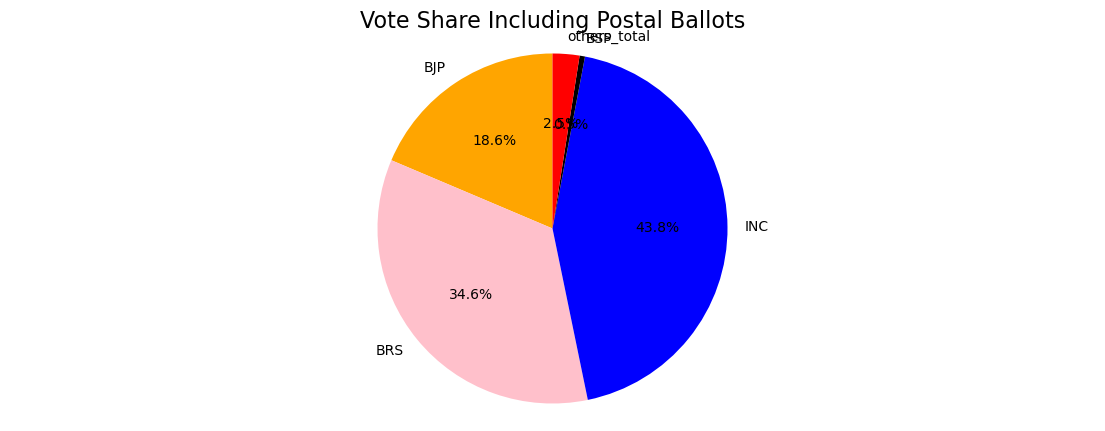

In [18]:
exclude = [
    'BJP', 'BRS', 'INC', 'BSP',
    'Polling Station No.', 'Polling Station Name',
    'Total of Valid Votes', 'No. Of Rejected Votes',
    'NOTA', 'Total', 'No. Of Tendered Votes','Sl. No.'
]

# Identify ONLY remaining candidate vote columns
other_cols = [c for c in df.columns if c not in exclude]

# Total votes from all other candidates
others_total = df[other_cols].sum().sum()

others_total

labels = ["BJP", "BRS", "INC", "BSP","others_total"]
sizes = [bjp_final, brs_final, inc_final, bsp_final, others_total]
colors = ["orange", "pink", "blue", "black","red"]

plt.figure(figsize=(14,5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Vote Share Including Postal Ballots", fontsize=16)
plt.axis("equal")
plt.show()


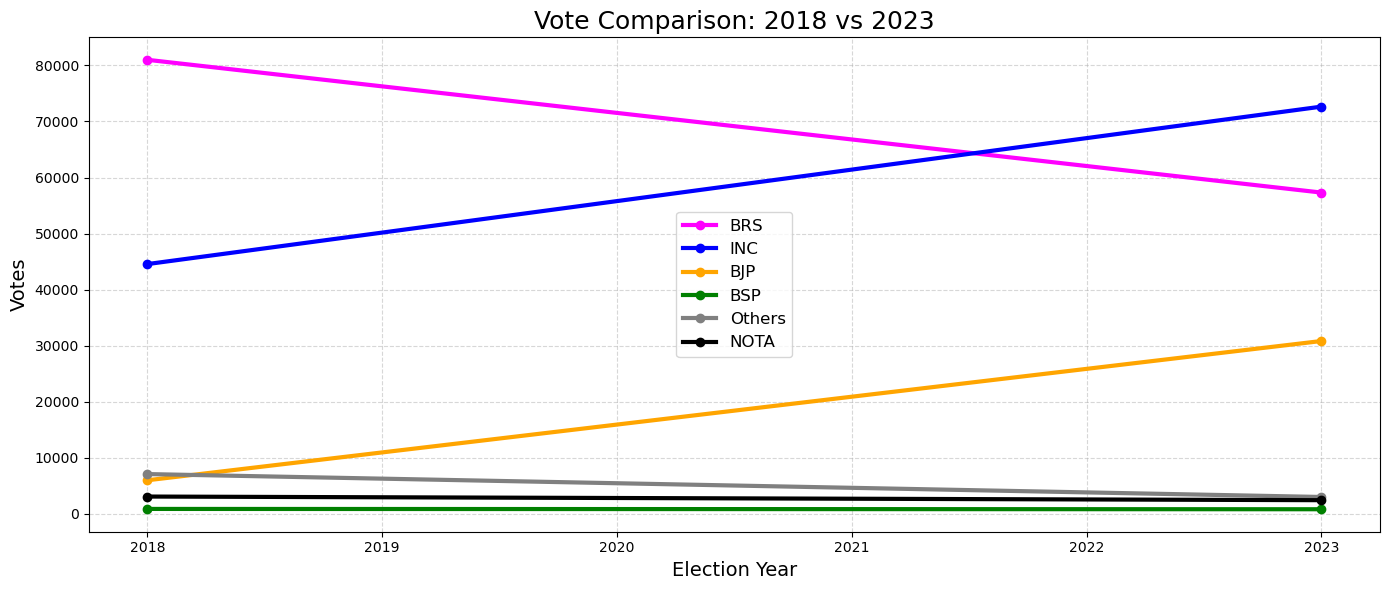

In [19]:

years = [2018, 2023]

BRS    = [81006, 57318]
INC    = [44555, 72649]
BJP    = [5979, 30826]
BSP    = [865, 808]
OTHERS = [7084, 2998]
NOTA   = [3075, 2426]

plt.figure(figsize=(14, 6))

# Plot each party
plt.plot(years, BRS,    marker='o', linewidth=3, color='magenta', label='BRS')
plt.plot(years, INC,    marker='o', linewidth=3, color='blue',    label='INC')
plt.plot(years, BJP,    marker='o', linewidth=3, color='orange',  label='BJP')
plt.plot(years, BSP,    marker='o', linewidth=3, color='green',   label='BSP')
plt.plot(years, OTHERS, marker='o', linewidth=3, color='gray',    label='Others')
plt.plot(years, NOTA,   marker='o', linewidth=3, color='black',   label='NOTA')

# Title and labels
plt.title("Vote Comparison: 2018 vs 2023", fontsize=18)
plt.xlabel("Election Year", fontsize=14)
plt.ylabel("Votes", fontsize=14)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Legend
plt.legend(fontsize=12)

# Display graph
plt.tight_layout()
plt.show()


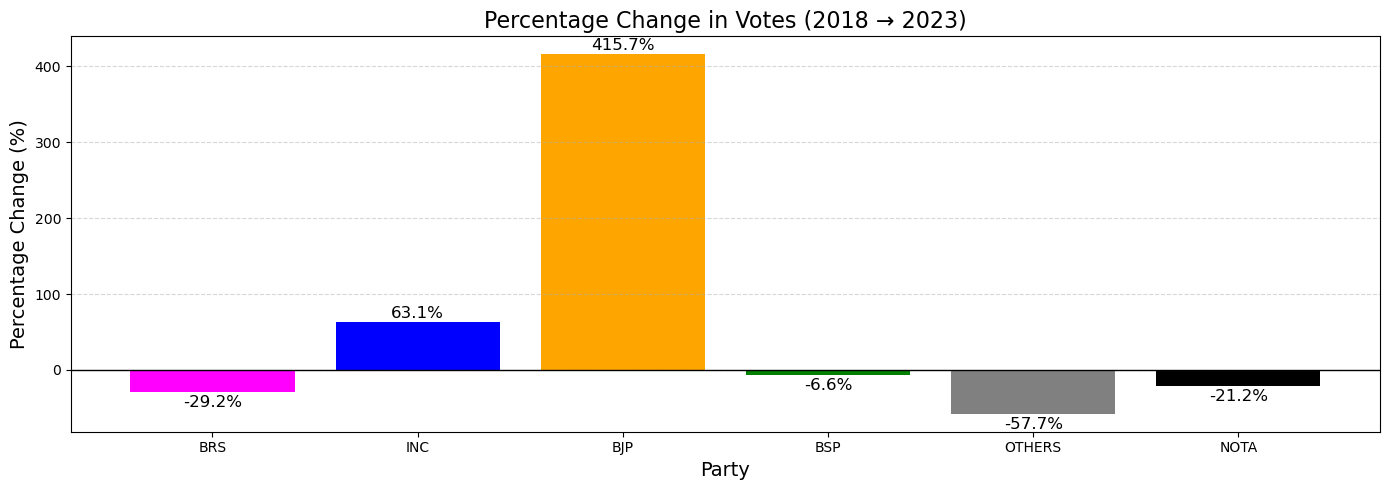

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Percentage changes calculated earlier
changes = {
    "BRS": -29.22,
    "INC": 63.09,
    "BJP": 415.74,
    "BSP": -6.59,
    "OTHERS": -57.67,
    "NOTA": -21.16
}

parties = list(changes.keys())
values = list(changes.values())

colors = [
    "magenta",   # BRS
    "blue",      # INC
    "orange",    # BJP
    "green",     # BSP
    "gray",      # Others
    "black"      # NOTA
]

plt.figure(figsize=(14, 5))

# Create vertical bars
bars = plt.bar(parties, values, color=colors)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (2 if height >= 0 else -4),
        f"{height:.1f}%",
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=12
    )

# Title and labels
plt.title("Percentage Change in Votes (2018 → 2023)", fontsize=16)
plt.ylabel("Percentage Change (%)", fontsize=14)
plt.xlabel("Party", fontsize=14)

# Add horizontal zero-line for clarity
plt.axhline(0, color='black', linewidth=1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
